# Notebook 4: Support Vector Machine (SVM) Model

## Objective

This notebook trains and evaluates a Support Vector Machine (SVM) model for Fake News Detection using TF-IDF features.

### Member

Pesara (CIT-24-01-0258)

### Machine Learning Model

Support Vector Machine (SVM)

### Deep Learning Model

Long Short-Term Memory (LSTM)

In [1]:
import joblib

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

In [2]:
X_train = joblib.load("../models/X_train_tfidf.pkl")
X_test = joblib.load("../models/X_test_tfidf.pkl")

y_train = joblib.load("../models/y_train.pkl")
y_test = joblib.load("../models/y_test.pkl")

In [3]:
print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (35744, 5000)
Testing Data : (8936, 5000)


In [4]:
svm_model = LinearSVC(
    random_state=42
)

##Why LinearSVC?

#For high-dimensional TF-IDF data, LinearSVC is usually faster and performs very well.

In [5]:
svm_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adj

In [6]:
y_pred = svm_model.predict(X_test)

In [7]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9916069829901522


In [8]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.9901199717713479


In [9]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.9922206506364922


In [10]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.9911691981631933


In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4694
           1       0.99      0.99      0.99      4242

    accuracy                           0.99      8936
   macro avg       0.99      0.99      0.99      8936
weighted avg       0.99      0.99      0.99      8936



In [12]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4652   42]
 [  33 4209]]


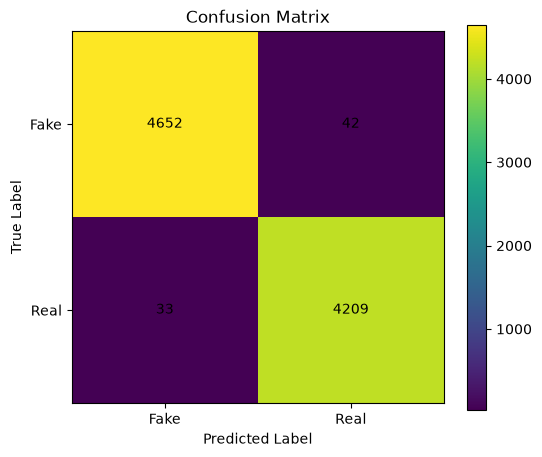

In [13]:
plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0,1],["Fake","Real"])
plt.yticks([0,1],["Fake","Real"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.show()

In [14]:
joblib.dump(
    svm_model,
    "../models/svm_model.pkl"
)

['../models/svm_model.pkl']

In [15]:
loaded_model = joblib.load(
    "../models/svm_model.pkl"
)

loaded_model.predict(X_test[:5])

array([1, 1, 1, 0, 1])

# Summary

This notebook successfully developed and evaluated a Support Vector Machine (SVM) model.

Completed tasks:

- Loaded TF-IDF feature vectors
- Trained the SVM classifier
- Generated predictions
- Evaluated model performance using:
  - Accuracy
  - Precision
  - Recall
  - F1 Score
  - Confusion Matrix
- Saved the trained SVM model

The trained model will later be compared with the LSTM model to identify the best-performing approach.